# Melanoma klasifikacija - Kompletni pipeline

Ovaj notebook sadrzi celokupan pipeline za klasifikaciju melanoma.


**Autori:** Jelena Adamovic, Milos Bojanic  
**Predmet:** SIAP  
**Dataset:** [ISIC Challenge 2020](https://www.kaggle.com/datasets/sumaiyabinteshahid/isic-challenge-dataset-2020)

---
## 0. Setup okruzenja

Proveravamo GPU, instaliramo zavisnosti i povezujemo Google Drive.

### 0.1 Provera GPU-a

Pre pokretanja ukljucimo GPU: `Runtime -> Change runtime type -> GPU (T4)`

In [ ]:
import torch
print(f"PyTorch: {torch.__version__}")
print(f"CUDA dostupna: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU memorija: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("UPOZORENJE: GPU NIJE DOSTUPAN!")
    print("Idite na Runtime -> Change runtime type -> GPU")

PyTorch: 2.10.0+cu128
CUDA dostupna: True
GPU: Tesla T4
GPU memorija: 15.6 GB


### 0.2 Instalacija zavisnosti

In [ ]:
!pip install -q timm albumentations mahotas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.8/5.8 MB 108.6 MB/s eta 0:00:00


### 0.3 Google Drive + src/ moduli

Povezujemo Google Drive gde se nalaze nasi `src/` Python moduli i gde cemo sacuvati rezultate.

In [ ]:
import os, sys, shutil
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Kopiramo src/ sa Drive-a na lokalni disk (za brze citanje)
REPO_DIR = '/content/melanoma-classification'
SRC_DRIVE = '/content/drive/MyDrive/melanoma_colab/src'
SRC_LOCAL = f'{REPO_DIR}/src'

if not os.path.exists(SRC_LOCAL):
    os.makedirs(REPO_DIR, exist_ok=True)
    shutil.copytree(SRC_DRIVE, SRC_LOCAL)
    print(f"src/ kopiran sa Drive-a na {SRC_LOCAL}")
else:
    print(f"src/ vec postoji na {SRC_LOCAL}")

sys.path.insert(0, REPO_DIR)

# Kreiramo folder za rezultate na Drive-u
RESULTS_DIR = '/content/drive/MyDrive/melanoma_results'
MODELS_DIR = f'{RESULTS_DIR}/models'
os.makedirs(MODELS_DIR, exist_ok=True)

print(f"\nsrc/ moduli dostupni: {os.path.exists(f'{SRC_LOCAL}/config.py')}")
print(f"Rezultati ce se cuvati u: {RESULTS_DIR}")

Mounted at /content/drive
src/ kopiran sa Drive-a na /content/melanoma-classification/src

src/ moduli dostupni: True
Rezultati ce se cuvati u: /content/drive/MyDrive/melanoma_results


---
## 1. Preuzimanje skupa podataka (dataset-a) sa Kaggle-a

Koristićemo **ISIC Challenge 2020** dataset, koji sadrži oko 33.000 dermoskopskih slika i zauzima otprilike 23 GB memorije.

Pre nego što počnemo, biće nam potreban Kaggle API ključ koji je smešten u ```kaggle.json``` fajlu. Kaggle API ključ smo dobili tako što smo ga generisali u podešavanjima na Kaggle platformi.



### 1.1 Kaggle API Setup

In [ ]:
from google.colab import files

if not os.path.exists(os.path.expanduser('~/.kaggle/kaggle.json')):
    print("Upload-ujte vas kaggle.json fajl:")
    uploaded = files.upload()
    !mkdir -p ~/.kaggle
    !mv kaggle.json ~/.kaggle/
    !chmod 600 ~/.kaggle/kaggle.json
    print("Kaggle API konfigurisan!")
else:
    print("Kaggle API vec konfigurisan.")

Upload-ujte vas kaggle.json fajl:


Saving kaggle.json to kaggle.json
Kaggle API konfigurisan!


### 1.2 Preuzimanje i raspakivanje

U zavisnosti od brzine interneta, preuzimanje dataset-a traje od 5 do 35 minuta, a samo raspakivanje fajlova traje oko 10 minuta.

Ukoliko se u toku preuzimanja fajlova prekine internet konekcija, koristićemo `shutil` biblioteku da uklonimo stare fajlove, a zatim ćemo pokrenuti novo preuzimanje fajlova od početka kako bismo imali bolju kontrolu nad preuzetim fajlovima.

In [ ]:
# import shutil
DATA_DIR = '/content/data'

# if os.path.exists(DATA_DIR):
#   print(f"Brisanje starog {DATA_DIR}...")
#   shutil.rmtree(DATA_DIR)

if not os.path.exists(DATA_DIR):
    os.makedirs(DATA_DIR, exist_ok=True)
    print("Preuzimanje dataseta sa Kaggle-a (~23GB)...")
    !kaggle datasets download -d sumaiyabinteshahid/isic-challenge-dataset-2020 -p {DATA_DIR}
    print("\nRaspakivanje...")
    !unzip -q {DATA_DIR}/*.zip -d {DATA_DIR}
    !rm -f {DATA_DIR}/*.zip
    print("Gotovo!")
else:
    print(f"Dataset vec postoji na {DATA_DIR}")

Brisanje starog /content/data...
Preuzimanje dataseta sa Kaggle-a (~23GB)...
Dataset URL: https://www.kaggle.com/datasets/sumaiyabinteshahid/isic-challenge-dataset-2020
License(s): CC0-1.0
100% 29.8G/29.8G [31:31<00:00, 16.9MB/s]


Raspakivanje...
Gotovo!


### 1.3 Pronalazenje strukture dataseta

Ovaj blok koda služi za verifikaciju učitanih podataka pre početka treniranja modela tako što obavlja tri ključne stvari:


1.   **Pronalaženje slika:** Prebrojava sve `.jpg` slike u folderu (uključujući i podfoldere) kako bi potvrdio da je dataset uspešno raspakovan.
2.   **Učitavanje metapodataka:** Čita CSV fajl koji sadrži informacije o slikama, poput dijagnoza i ID-jeva pacijenata.
3. **Statistička provera:** Proverava balans klasa, odnosno koliko ima benignih, a koliko malignih promena. Ovakve informacije su kritične za medicinske skupove podataka.

Dodatno, identifikuje broj unikatnih pacijenata kako bi se osiguralo da podaci istog pacijenta ne završe i u trening i u test skupu.







In [ ]:
import os
import glob
import pandas as pd

TRAIN_DIR = "/content/data/ISIC_2020_Dataset/train"
TRAIN_CSV = "/content/data/ISIC_2020_Dataset/ISIC_2020_Train_Metadata.csv"

jpg_files = glob.glob(os.path.join(TRAIN_DIR, "**/*.jpg"), recursive=True)
if not jpg_files:
    jpg_files = glob.glob(os.path.join(TRAIN_DIR, "**/*.JPG"), recursive=True)

print(f"Uspeh! Pronađeno slika: {len(jpg_files)}")

if os.path.exists(TRAIN_CSV):
    df_info = pd.read_csv(TRAIN_CSV)
    print(f"\nBroj redova u CSV: {len(df_info)}")

    if 'target' in df_info.columns:
        print(f"\nRaspodela klasa:")
        benign = (df_info['target'] == 0).sum()
        malignant = (df_info['target'] == 1).sum()
        total = len(df_info)
        print(f"  Benign:    {benign} ({benign/total*100:.1f}%)")
        print(f"  Malignant: {malignant} ({malignant/total*100:.1f}%)")

    if 'patient_id' in df_info.columns:
        print(f"\nBroj unikatnih pacijenata: {df_info['patient_id'].nunique()}")
else:
    print(f"CSV fajl nije pronađen na putanji: {TRAIN_CSV}")

Uspeh! Pronađeno slika: 33126

Broj redova u CSV: 33126

Raspodela klasa:
  Benign:    32542 (98.2%)
  Malignant: 584 (1.8%)

Broj unikatnih pacijenata: 2056


Iz rezultata ove analize zaključujemo da je dataset jako nebalansiran (~98% benignih, ~2% malignih). Iz tog razloga, koristićemo `pos_weight` u loss funkciji i stratifikovanu cross-validaciju.

### 1.4 Primer slike iz dataseta

U ovom bloku koda vršimo prikaz nasumično odabranog primera iz našeg skupa podataka. Proces se odvija u tri koraka:


1.   Na osnovu imena slike iz CSV fajla, program pronalazi ofgovarajući `.jpg` fajl na disku.
2. Pošto biblioteka `OpenCV` (cv2) standardno učitava slike u BGR formatu, vršimo konverziju u RGB kako bi boje na ekranu izgledale prirodno.
3. Pored prikaza same slike, ispisujemo i njene dimenzije (rezoluciju i broj kanala boja), što nam pomaže da planiramo korak promene veličine (resizing) pre slanja u neuronsku mrežu.


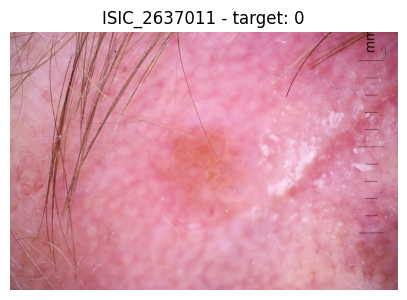

Dimenzije slike: (4000, 6000, 3)


In [ ]:
import cv2
import matplotlib.pyplot as plt

sample = df_info.iloc[0]
sample_path = os.path.join(TRAIN_DIR, f"{sample['image_name']}.jpg")
img = cv2.cvtColor(cv2.imread(sample_path), cv2.COLOR_BGR2RGB)

plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.title(f"{sample['image_name']} - target: {sample['target']}")
plt.axis('off')
plt.show()
print(f"Dimenzije slike: {img.shape}")

---
## 2. Konfiguracija i preprocessing

Postavljamo konfiguraciju i prikazujemo korake preprocesiranja.

### 2.1 Konfiguracija

Ovaj deo koda je posvećen podešavanju okruženja i hiperparametara koristeći za to prilagođenu klasu `Config`. Glavne svrhe ovog dela koda su:


*   **Podešavanje putanja:** Mapiramo gde se nalaze podaci za treniranje (`train_dir`) i gde će se čuvati istrenirani modeli (`model_save_dir`).
*   **Definisanje trening parametara:** Postavljamo ključne vrednosti za učenje, kao što su broj epoha, veličina batch-a i broj foldova za kros-validaciju.
* **Detekcija hardvera:** Metoda `get_device()` automatski proverava da li je dostupna grafička kartica (GPU) ili će se model trenirati na procesoru (CPU).

Sve izmene u eksperimentu (npr. promena broja epoha) vrše se samo na ovom mestu, što osigurava konzistentnost kroz ceo kod.







In [ ]:
from src.config import Config

cfg = Config.colab()
cfg.train_csv = TRAIN_CSV
cfg.train_dir = TRAIN_DIR
cfg.model_save_dir = MODELS_DIR

print(f"Device: {cfg.get_device()}")
print(f"Epochs: {cfg.epochs}")
print(f"Folds: {cfg.num_folds}")
print(f"Batch size: {cfg.batch_size}")
print(f"Train CSV: {cfg.train_csv}")
print(f"Train DIR: {cfg.train_dir}")
print(f"Models DIR: {cfg.model_save_dir}")

Device: cuda
Epochs: 20
Folds: 5
Batch size: 32
Train CSV: /content/data/ISIC_2020_Dataset/ISIC_2020_Train_Metadata.csv
Train DIR: /content/data/ISIC_2020_Dataset/train
Models DIR: /content/drive/MyDrive/melanoma_results/models


### 2.2 Uklanjanje dlaka (Hair Removal)

Dermoskopske slike cesto sadrze dlake koje mogu omesti klasifikaciju. Koristimo **Black-Hat morfolosku transformaciju** za detekciju dlaka, a zatim **Telea inpainting algoritam** za njihovo uklanjanje.

Postupak:
1. Konvertovanje u grayscale
2. Black-Hat transformacija sa strukturnim elementom (15x15)
3. Binarizacija maske (prag = 10)
4. Inpainting koristeci Telea algoritam

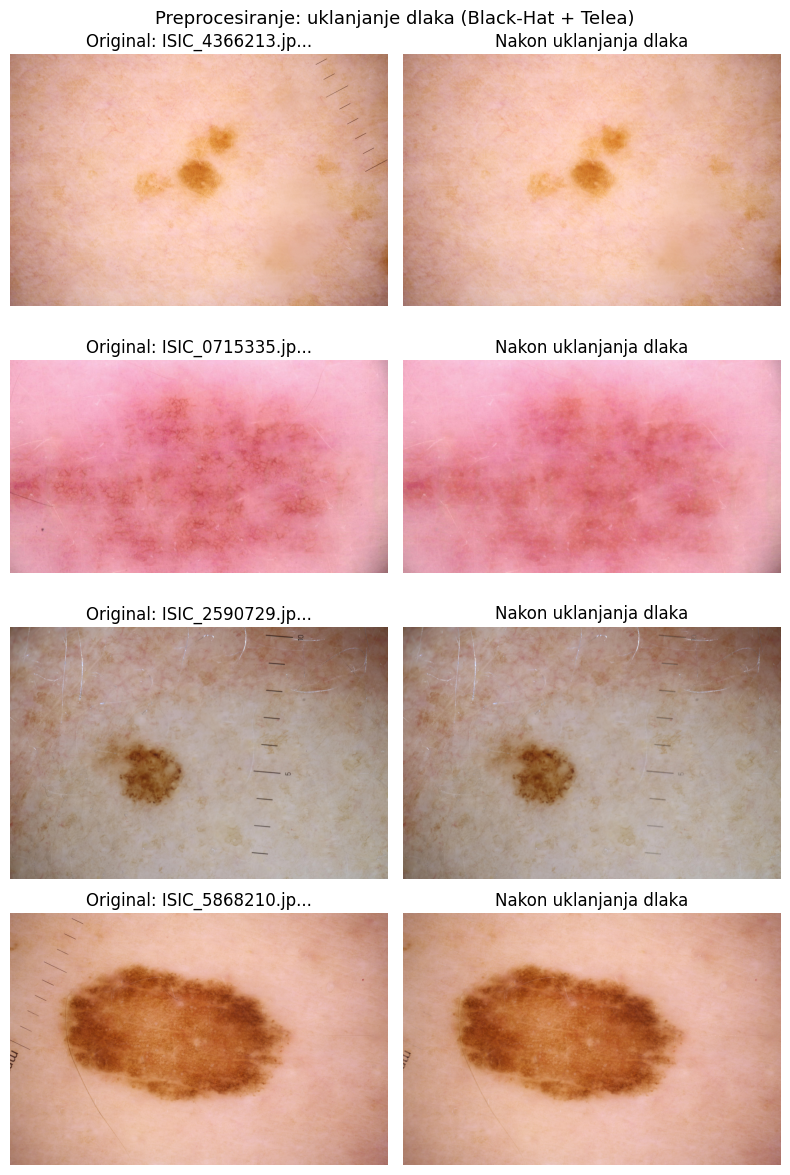

In [ ]:
import numpy as np
from src.preprocessing import remove_hairs
from src.visualization import plot_preprocessing_examples

fig = plot_preprocessing_examples(cfg.train_dir, n=4)
plt.show()

Black-Hat transformacija uspesno detektuje tamne linearne strukture (dlake) na svetloj kozi, a Telea inpainting ih zamenjuje okolnim pikselima.

### 2.3 Ekstrakcija Hu momenata

**Hu momenti** su 7 invarijantnih momenata koji opisuju oblik objekta na slici. Invarijantni su na translaciju, skaliranje i rotaciju. Koristimo **prva 4 Hu momenta** sa log-transformacijom za numericku stabilnost.

In [ ]:
from src.features import calculate_hu_moments

img_files = [f for f in os.listdir(cfg.train_dir) if f.endswith('.jpg')][:8]
hu_data = []

for fname in img_files:
    img = cv2.imread(os.path.join(cfg.train_dir, fname))
    cleaned = remove_hairs(img)
    hu = calculate_hu_moments(cleaned, n_moments=4)
    hu_data.append({
        'image': fname[:20],
        'Hu1': f'{hu[0]:.4f}',
        'Hu2': f'{hu[1]:.4f}',
        'Hu3': f'{hu[2]:.4f}',
        'Hu4': f'{hu[3]:.4f}',
    })

hu_df = pd.DataFrame(hu_data)
print("Hu momenti za primere slika (log-transformisani):")
hu_df

Hu momenti za primere slika (log-transformisani):


,image,Hu1,Hu2,Hu3,Hu4
0,ISIC_2748736.jpg,3.0982,7.0352,9.9992,9.9999
1,ISIC_1167108.jpg,3.1285,7.8900,9.9643,9.9954
2,ISIC_5631712.jpg,3.1660,7.6666,9.9976,9.9996
3,ISIC_8760029.jpg,3.1791,7.5599,9.9980,10.0000
4,ISIC_8570817.jpg,3.1101,7.2978,9.9995,9.9987
5,ISIC_7959669.jpg,3.0915,7.3594,9.9987,9.9998
6,ISIC_3311099.jpg,3.0632,6.6965,9.9973,9.9951
7,ISIC_7396015.jpg,3.1630,7.8233,9.9891,9.9999


Hu momenti se razlikuju
između slika, što znači da nose informaciju o obliku lezije. Koriste se kao dodatni ulaz u model (late fusion).

### 2.4 Enkodiranje metapodataka

Pored vizuelnih obelezja, koristimo i metapodatke pacijenata:
- **Pol** (sex) - one-hot enkodiranje
- **Anatomska lokacija** (anatom_site_general_challenge) - one-hot enkodiranje
- **Starost** (age_approx) - min-max normalizacija na [0, 1]

In [ ]:
from src.features import encode_metadata

df_demo = pd.read_csv(cfg.train_csv)
df_encoded, metadata_cols, metadata_dim = encode_metadata(df_demo)

print(f"Metadata kolone ({metadata_dim}): {metadata_cols}")
print(f"\nPrimer enkodiranih metapodataka (prvih 5 redova):")
df_encoded[metadata_cols].head()

Metadata kolone (11): ['sex_female', 'sex_male', 'sex_unknown', 'site_head/neck', 'site_lower extremity', 'site_oral/genital', 'site_palms/soles', 'site_torso', 'site_unknown', 'site_upper extremity', 'age_norm']

Primer enkodiranih metapodataka (prvih 5 redova):


,sex_female,sex_male,sex_unknown,site_head/neck,site_lower extremity,site_oral/genital,site_palms/soles,site_torso,site_unknown,site_upper extremity,age_norm
0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.500000
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.500000
2,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.555556
3,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.500000
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.611111


Svaki pacijent ima numericki vektor metapodataka. Ovaj vektor se spaja sa Hu momentima (4 vrednosti) u drugoj grani modela (late fusion).

### 2.5 Augmentacija podataka

Zbog izrazitog disbalansa klasa koristimo **on-the-fly augmentaciju** tokom treniranja:
- Horizontalni i vertikalni flip, rotacija za 90 stepeni
- Shift-Scale-Rotate, ColorJitter
- Normalizacija (ImageNet mean/std)

Augmentacija se primenjuje samo na trening skup. Ovaj pristup ne može da izazove curenje podataka između foldova.

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


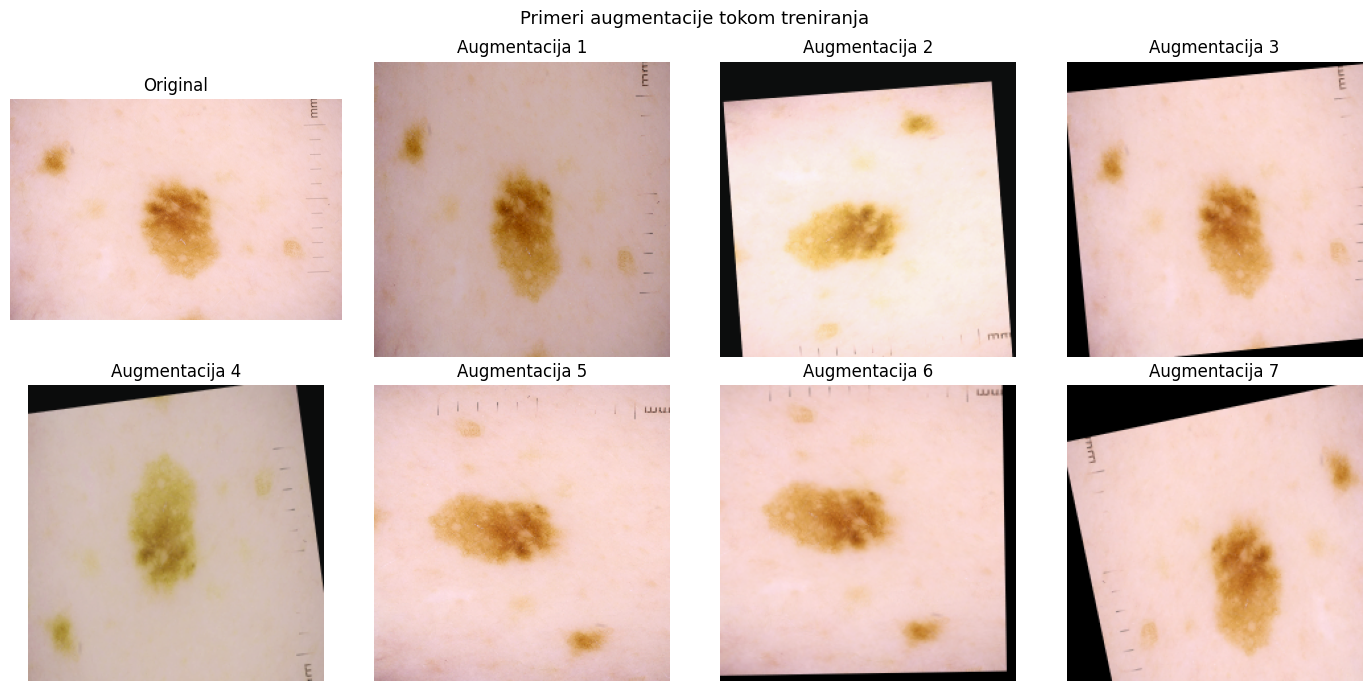

In [ ]:
from src.augmentation import get_train_transforms

train_t = get_train_transforms(cfg.image_size)

sample_img = cv2.imread(os.path.join(cfg.train_dir, img_files[0]))
sample_rgb = cv2.cvtColor(sample_img, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes[0, 0].imshow(sample_rgb)
axes[0, 0].set_title('Original')
axes[0, 0].axis('off')

for i in range(1, 8):
    row, col = divmod(i, 4)
    augmented = train_t(image=sample_rgb)['image']
    img_show = augmented.permute(1, 2, 0).numpy()
    img_show = img_show * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img_show = np.clip(img_show, 0, 1)
    axes[row, col].imshow(img_show)
    axes[row, col].set_title(f'Augmentacija {i}')
    axes[row, col].axis('off')

fig.suptitle('Primeri augmentacije tokom treniranja', fontsize=13)
plt.tight_layout()
plt.show()

Augmentacija generise različite varijacije iste slike, sto smanjuje overfitting, što je posebno značajno za malobrojnu malignu klasu.

### 2.6 Preprocesiranje svih slika

Ovo je ključni korak za poboljšanje performansi treniranja mdoela. Umesto da za svaku sliku radimo resize + hair removal + Hu momente tokom treniranja (što se ponavlja u svakoj epohi), **uradićemo to jednom za sve slike** i sačuvati rezultate.

Preprocesiramo za oba modela unapred:
- **128x128** za Custom CNN
- **224x224** za EfficientNet

Ovo traje duže od sat vremena, ali posle toga treniranje je **drastično brže** jer DataLoader samo čita gotove numpy fajlove.

In [ ]:
from src.preprocessing_cache import preprocess_and_cache
from src.data_utils import load_and_prepare_data

# Ucitavamo podatke (potrebno za listu slika)
df = load_and_prepare_data(cfg)
print(f"Ukupno slika za preprocesiranje: {len(df)}")

# Preprocesiranje za CNN (128x128)
CNN_CACHE = "/content/preprocessed_128"
print("[1/2] Preprocesiranje za CNN (128x128)...")
preprocess_and_cache(df, cfg.train_dir, CNN_CACHE, image_size=128,
                     apply_hair_removal=cfg.apply_hair_removal)

# Preprocesiranje za EfficientNet (224x224)
# EFFNET_CACHE = "/content/preprocessed_224"
# print("[2/2] Preprocesiranje za EfficientNet (224x224)...")
# preprocess_and_cache(df, cfg.train_dir, EFFNET_CACHE, image_size=224,
#                      apply_hair_removal=cfg.apply_hair_removal)

print("Preprocesiranje zavrseno! Slike su spremne za treniranje.")

Ukupno slika za preprocesiranje: 33126
[1/2] Preprocesiranje za CNN (128x128)...


Preprocessing 128x128: 100%|██████████| 33126/33126 [50:53<00:00, 10.85it/s]

Done! 33126 images cached in /content/preprocessed_128
Preprocesiranje zavrseno! Slike su spremne za treniranje.


Nakon ovog koraka, sve slike su preprocesirane i sačuvane kao numpy fajlovi. Tokom treniranja, DataLoader samo čita gotove fajlove umesto da ponovo radi resize, hair removal i ekstrakciju Hu momenata za svaku sliku u svakoj epohi. Ovo ubrzava treniranje od 10 do 100 puta.

---
## 3. Treniranje Custom CNN modela

Nas Custom CNN model se sastoji od:
- **3 konvoluciona sloja** (32->64->128 filtera) sa BatchNorm i ReLU
- **AdaptiveAvgPool** -> vektor od 128 dimenzija
- **Late fusion**: spajanje vizuelnih obelezja (128-dim) sa metapodacima (Hu momenti + encoded metadata)
- **Klasifikator**: FC(128+feat_dim -> 64) -> FC(64 -> 1)

Treniramo sa:
- **StratifiedGroupKFold** - podela po pacijentima (sprečava curenje podataka)
- **BCEWithLogitsLoss** sa pos_weight za balansiranje klasa
- **Early stopping** na osnovu validacionog AUC-ROC

In [ ]:
from src.data_utils import load_and_prepare_data
from src.training import run_cross_validation
from src.visualization import plot_all_folds_losses, plot_roc_curve, plot_fold_comparison

### 3.1 Konfiguracija CNN-a

In [ ]:
cfg.model_type = 'cnn'
cfg.image_size = 128
cfg.cache_dir = CNN_CACHE  # Koristi preprocesirane slike
cfg.loss_type = 'focal'  # 'bce' = weighted BCE (default), 'focal' = Focal Loss

print(f"Model: {cfg.model_type}")
print(f"Image size: {cfg.image_size}x{cfg.image_size}")
print(f"Epochs: {cfg.epochs}, Folds: {cfg.num_folds}")
print(f"Batch size: {cfg.batch_size}")
print(f"Device: {cfg.get_device()}")

Model: cnn
Image size: 128x128
Epochs: 20, Folds: 5
Batch size: 32
Device: cuda


### 3.2 Učitavanje podataka

Ovaj blok transformiše sirove podatke u format koji je spreman za model. U prvom koraku poziva funkciju koja povezuje slike sa tabelom iz CSV-a i čisti podatke. Zatim u drugom koraku prikazuje finalni broj slika i balans klasa (procenat benignih i malignih promena). Naposletku, proverava broj unikatnih pacijenata i dimenzije ulaza za model.

In [ ]:
df = load_and_prepare_data(cfg)

print(f"Ukupno slika: {len(df)}")
print(f"Raspodela klasa:")
print(f"  Benign:    {(df['target'] == 0).sum()} ({(df['target'] == 0).mean()*100:.1f}%)")
print(f"  Malignant: {(df['target'] == 1).sum()} ({(df['target'] == 1).mean()*100:.1f}%)")
print(f"Broj pacijenata: {df['patient_id'].nunique()}")
print(f"Feature dim: {cfg.feature_dim}")

Ukupno slika: 33126
Raspodela klasa:
  Benign:    32542 (98.2%)
  Malignant: 584 (1.8%)
Broj pacijenata: 2056
Feature dim: 15


### 3.3 Treniranje sa k-fold cross-validacijom


In [ ]:
cnn_results = run_cross_validation(df, cfg)


Target distribution: {0: 32542, 1: 584}
Running 5-fold CV with cnn model


--- Fold 1/5 ---
  Train: 26466 samples (462 malignant)
  Val:   6660 samples (122 malignant)


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
Train:   0%|          | 0/828 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader 

  Fold 0 | Epoch 1/20 | Train Loss: 0.1371 | Val Loss: 0.1143 | Val AUC: 0.7987 | Val Acc: 0.9574


Train:   0%|          | 0/828 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


  Fold 0 | Epoch 2/20 | Train Loss: 0.1273 | Val Loss: 0.1170 | Val AUC: 0.7658 | Val Acc: 0.9689


...

  Fold 4 | Epoch 18/20 | Train Loss: 0.1114 | Val Loss: 0.1277 | Val AUC: 0.7897 | Val Acc: 0.8540


Train:   0%|          | 0/834 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


  Fold 4 | Epoch 19/20 | Train Loss: 0.1111 | Val Loss: 0.1217 | Val AUC: 0.8305 | Val Acc: 0.9453


Train:   0%|          | 0/834 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
                                                      

  Fold 4 | Epoch 20/20 | Train Loss: 0.1105 | Val Loss: 0.1212 | Val AUC: 0.8209 | Val Acc: 0.9202

Cross-Validation Results (cnn)
Mean AUC: 0.8345 +/- 0.0173
Per-fold AUCs: ['0.8421', '0.8448', '0.8524', '0.8028', '0.8305']


### 3.4 Vizualizacija rezultata CNN-a

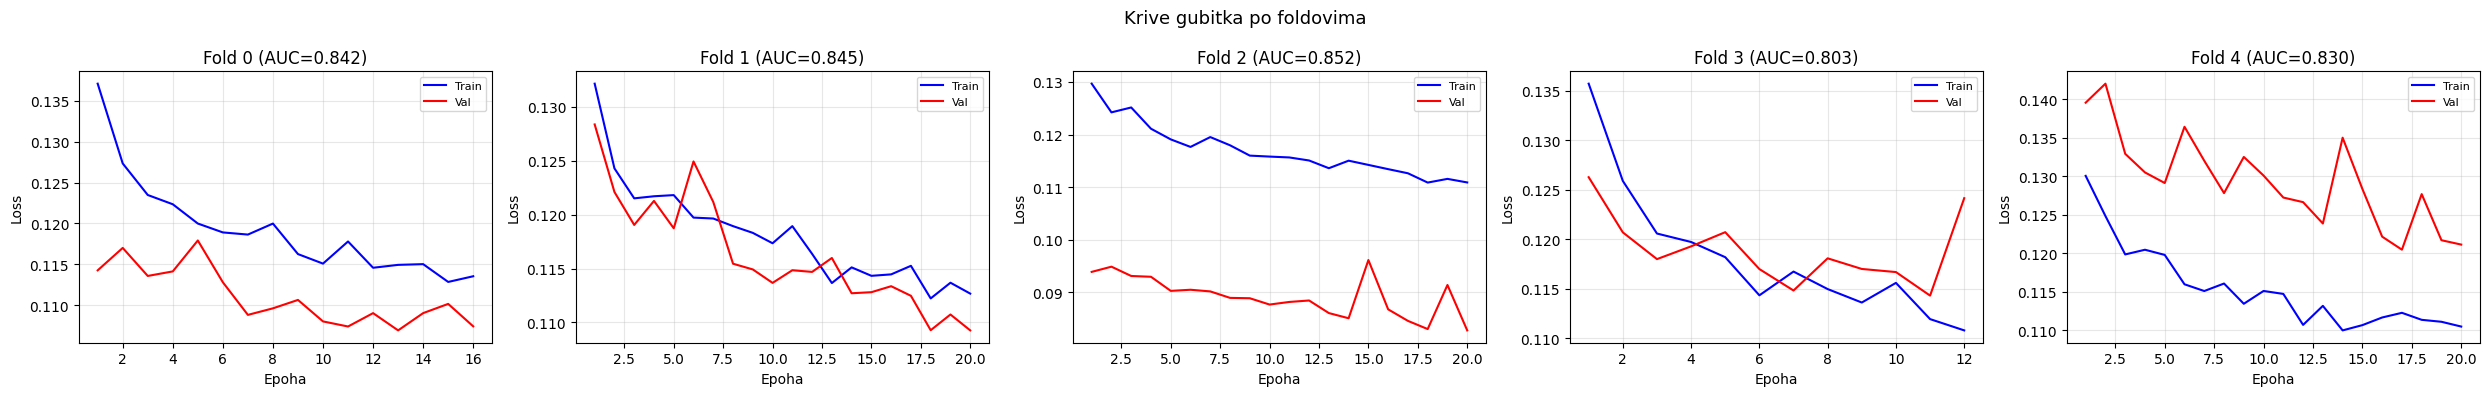

In [ ]:
# Krive gubitka po foldovima
fig = plot_all_folds_losses(cnn_results['per_fold_results'])
plt.show()

Train loss opada kroz epohe. Ako val loss počne da raste dok train loss opada, to ukazuje na overfitting, pa early stopping zaustavlja treniranje pre toga.

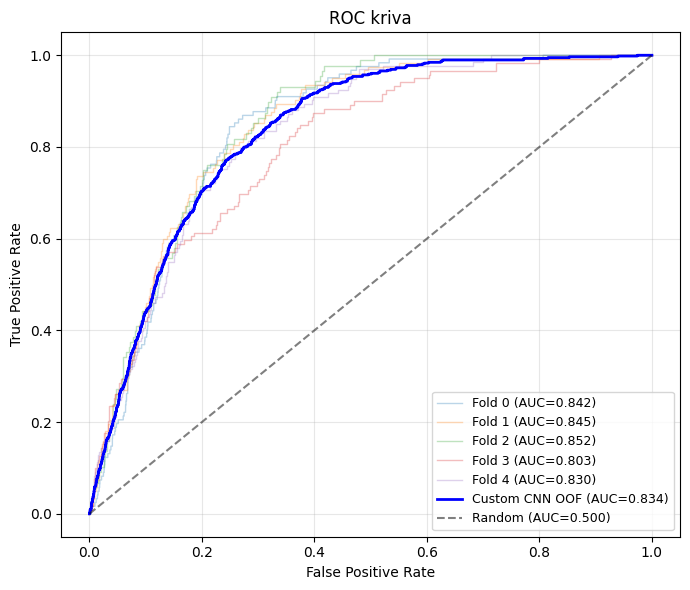

In [ ]:
# ROC kriva
fig = plot_roc_curve(
    cnn_results['oof_labels'],
    cnn_results['oof_probs'],
    fold_results=cnn_results['per_fold_results'],
    label='Custom CNN'
)
plt.show()

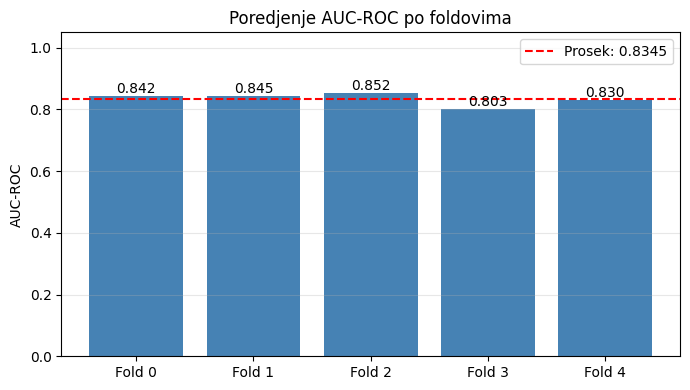


CNN Mean AUC: 0.8345 +/- 0.0173


In [ ]:
# Poredjenje AUC po foldovima
fig = plot_fold_comparison(cnn_results['per_fold_results'])
plt.show()

print(f"\nCNN Mean AUC: {cnn_results['mean_auc']:.4f} +/- {cnn_results['std_auc']:.4f}")

### 3.5 Cuvanje CNN rezultata na Drive

In [ ]:
import pickle

cnn_save_path = os.path.join(RESULTS_DIR, 'cnn_results.pkl')
with open(cnn_save_path, 'wb') as f:
    pickle.dump({
        'oof_labels': cnn_results['oof_labels'],
        'oof_probs': cnn_results['oof_probs'],
        'oof_df': cnn_results['oof_df'],
        'mean_auc': cnn_results['mean_auc'],
        'std_auc': cnn_results['std_auc'],
        'per_fold_aucs': [r['best_val_auc'] for r in cnn_results['per_fold_results']],
    }, f)

print(f"CNN rezultati sacuvani u: {cnn_save_path}")

CNN rezultati sacuvani u: /content/drive/MyDrive/melanoma_results/cnn_results.pkl


Nakon ovog koraka, Custom CNN model je treniran. Rezultati su sačuvani na Google Drive-u za slučaj da se sesija prekine pre EfficientNet treniranja.

---
## 4. Treniranje EfficientNet B0 modela

**EfficientNet B0** je pretreniran model na ImageNet datasetu (transfer learning).

Arhitektura:
- **EfficientNet B0 backbone** (pretreniran na ImageNet) -> 1280-dim vektor
- **Late fusion**: spajanje sa metapodacima (Hu momenti + encoded metadata)
- **Klasifikator**: FC(1280+feat_dim -> 256) -> FC(256 -> 1)

Očekujemo bolje rezultate od Custom CNN-a jer koristi transfer learning sa milionima slika.

### 4.1 Konfiguracija EfficientNet-a

U ovom koraku podešavamo okruženje za treniranje EfficientNet B0 modela.

In [ ]:
cfg.model_type = 'efficientnet'
cfg.image_size = 224
cfg.cache_dir = EFFNET_CACHE  # Koristi preprocesirane slike
cfg.loss_type = 'focal'  # 'bce' = weighted BCE (default), 'focal' = Focal Loss

print(f"Model: {cfg.model_type}")
print(f"Image size: {cfg.image_size}x{cfg.image_size}")
print(f"Epochs: {cfg.epochs}, Folds: {cfg.num_folds}")
print(f"Batch size: {cfg.batch_size}")
print(f"Device: {cfg.get_device()}")

### 4.2 Treniranje sa k-fold cross-validacijom

Treniranje EfficientNet B0 modela traje malo duže od treniranja klasične konvolutivne neuronske mreže jer koristi veće slike (224x224 naspram 128x128 kod CNN-a) i model je sam po sebi složeniji.

In [ ]:
effnet_results = run_cross_validation(df, cfg)

### 4.3 Vizualizacija rezultata EfficientNet-a

U ovom delu koda generišemo grafikone koji nam služe za slikovni prikaz procesa učenja kod EfficientNet B0 modela.

In [ ]:
fig = plot_all_folds_losses(effnet_results['per_fold_results'])
plt.show()

In [ ]:
fig = plot_roc_curve(
    effnet_results['oof_labels'],
    effnet_results['oof_probs'],
    fold_results=effnet_results['per_fold_results'],
    label='EfficientNet B0'
)
plt.show()

In [ ]:
fig = plot_fold_comparison(effnet_results['per_fold_results'])
plt.show()

print(f"\nEfficientNet Mean AUC: {effnet_results['mean_auc']:.4f} +/- {effnet_results['std_auc']:.4f}")

### 4.4 Cuvanje EfficientNet rezultata na Drive

Kao i kod obične CNN, rezultate treniranja čuvamo na disku kako bismo ih imali sačuvane ukoliko se sesija prekine ili ako zbog limita moramo da pređemo na drugi nalog.

In [ ]:
effnet_save_path = os.path.join(RESULTS_DIR, 'effnet_results.pkl')
with open(effnet_save_path, 'wb') as f:
    pickle.dump({
        'oof_labels': effnet_results['oof_labels'],
        'oof_probs': effnet_results['oof_probs'],
        'oof_df': effnet_results['oof_df'],
        'mean_auc': effnet_results['mean_auc'],
        'std_auc': effnet_results['std_auc'],
        'per_fold_aucs': [r['best_val_auc'] for r in effnet_results['per_fold_results']],
    }, f)

print(f"EfficientNet rezultati sacuvani u: {effnet_save_path}")

Nakon ovog koraka, EfficientNet model je treniran. Oba modela su sačuvana na Drive-u.

---
## 5. Evaluacija i poređenje modela

U ovom koraku poredimo performanse Custom CNN i EfficientNet B0 modela koristeći *out-of-fold* (OOF) predikcije iz kros-validacije.

Fokusiramo se na tri ključne metrike:

* **AUC-ROC:** Naša primarna metrika. Ona nam pokazuje koliko dobro model razlikuje klase bez obzira na prag klasifikacije. Što je AUC veći, to je model pouzdaniji.

* **Recall (Senzitivnost):** Verovatno najvažnija metrika u medicini. Ona meri procenat uspešno detektovanih malignih slučajeva. Cilj nam je da ovaj broj bude što veći kako ne bismo propustili nijednu potencijalnu dijagnozu.

* **Precision (Preciznost):** Pokazuje koliki je procenat stvarno pozitivnih nalaza među svim slikama koje je model označio kao maligne.

In [ ]:
from src.evaluation import compute_metrics, compute_metrics_at_best_threshold
from src.visualization import plot_roc_comparison, plot_confusion_matrix

### 5.1 Poredjenje ROC krivih

ROC kriva prikazuje odnos između True Positive Rate (Recall) i False Positive Rate za različite pragove klasifikacije.

In [ ]:
fig = plot_roc_comparison({
    'Custom CNN': cnn_results,
    'EfficientNet B0': effnet_results,
})
plt.show()

print(f"CNN AUC:         {cnn_results['mean_auc']:.4f} +/- {cnn_results['std_auc']:.4f}")
print(f"EfficientNet AUC: {effnet_results['mean_auc']:.4f} +/- {effnet_results['std_auc']:.4f}")

# PR-AUC (informativnija metrika za nebalansirane podatke)
from sklearn.metrics import average_precision_score
cnn_pr_auc = average_precision_score(cnn_results["oof_labels"], cnn_results["oof_probs"])
effnet_pr_auc = average_precision_score(effnet_results["oof_labels"], effnet_results["oof_probs"])
print(f"\nCNN PR-AUC:         {cnn_pr_auc:.4f}")
print(f"EfficientNet PR-AUC: {effnet_pr_auc:.4f}")
print("\nNapomena: PR-AUC je stroža metrika od ROC-AUC za nebalansirane podatke.")

### 5.2 Detaljne metrike klasifikacije

Metrike za oba modela izračunavamo na dva načina kako bismo dobili potpuniju sliku:
* **Fiksni prag (0.5):** Koristimo standardnu podrazumevanu vrednost za klasifikaciju.
* **Optimalni prag:** Pronalazimo vrednost koja maksimizuje Youden’s J statistiku (TPR - FPR). Ovaj pristup nam pomaže da pronađemo idealan balans između osetljivosti (Recall) i specifičnosti modela, što je često efikasnije od korišćenja fiksne granice.

In [ ]:
cnn_metrics = compute_metrics(cnn_results['oof_labels'], cnn_results['oof_probs'], threshold=0.5)
effnet_metrics = compute_metrics(effnet_results['oof_labels'], effnet_results['oof_probs'], threshold=0.5)

cnn_optimal, cnn_thresh = compute_metrics_at_best_threshold(cnn_results['oof_labels'], cnn_results['oof_probs'])
effnet_optimal, effnet_thresh = compute_metrics_at_best_threshold(effnet_results['oof_labels'], effnet_results['oof_probs'])

comparison = pd.DataFrame({
    'Metrika': ['AUC-ROC', 'PR-AUC', 'Accuracy', 'Recall', 'Precision', 'F1-score', 'Prag'],
    'CNN (prag=0.5)': [
        f"{cnn_metrics['auc_roc']:.4f}",
        f"{cnn_metrics['pr_auc']:.4f}",
        f"{cnn_metrics['accuracy']:.4f}",
        f"{cnn_metrics['recall']:.4f}",
        f"{cnn_metrics['precision']:.4f}",
        f"{cnn_metrics['f1']:.4f}",
        '0.5000',
    ],
    'CNN (optimalni)': [
        f"{cnn_optimal['auc_roc']:.4f}",
        f"{cnn_optimal['pr_auc']:.4f}",
        f"{cnn_optimal['accuracy']:.4f}",
        f"{cnn_optimal['recall']:.4f}",
        f"{cnn_optimal['precision']:.4f}",
        f"{cnn_optimal['f1']:.4f}",
        f"{cnn_thresh:.4f}",
    ],
    'EfficientNet (prag=0.5)': [
        f"{effnet_metrics['auc_roc']:.4f}",
        f"{effnet_metrics['pr_auc']:.4f}",
        f"{effnet_metrics['accuracy']:.4f}",
        f"{effnet_metrics['recall']:.4f}",
        f"{effnet_metrics['precision']:.4f}",
        f"{effnet_metrics['f1']:.4f}",
        '0.5000',
    ],
    'EfficientNet (optimalni)': [
        f"{effnet_optimal['auc_roc']:.4f}",
        f"{effnet_optimal['pr_auc']:.4f}",
        f"{effnet_optimal['accuracy']:.4f}",
        f"{effnet_optimal['recall']:.4f}",
        f"{effnet_optimal['precision']:.4f}",
        f"{effnet_optimal['f1']:.4f}",
        f"{effnet_thresh:.4f}",
    ],
})

print("Poredjenje modela (Out-of-Fold predikcije):")
comparison

U medicinskoj dijagnostici, Recall (senzitivnost) ima prioritet jer direktno utiče na sigurnost pacijenata. Visok Recall minimizuje broj lažno negativnih rezultata, čime osiguravamo da nijedan maligni slučaj ne prođe neprimećen. Naš primarni cilj je postizanje maksimalne osetljivosti uz održavanje razumne preciznosti, kako bismo izbegli preveliki broj nepotrebnih daljih ispitivanja.

### 5.3 Matrice konfuzije

Prikazujemo matrice konfuzije za oba modela sa **optimalnim pragom**.

In [ ]:
print("=== Custom CNN ===")
cnn_preds_opt = (cnn_results['oof_probs'] >= cnn_thresh).astype(int)
fig = plot_confusion_matrix(cnn_results['oof_labels'], cnn_preds_opt,
                            title=f'Custom CNN (prag={cnn_thresh:.3f})')
plt.show()

print("\n=== EfficientNet B0 ===")
effnet_preds_opt = (effnet_results['oof_probs'] >= effnet_thresh).astype(int)
fig = plot_confusion_matrix(effnet_results['oof_labels'], effnet_preds_opt,
                            title=f'EfficientNet B0 (prag={effnet_thresh:.3f})')
plt.show()

### 5.4 Classification Report

In [ ]:
print("=== Custom CNN (optimalni prag) ===")
print(cnn_optimal['classification_report'])

print("\n=== EfficientNet B0 (optimalni prag) ===")
print(effnet_optimal['classification_report'])

EfficientNet B0 sa transfer learning-om očekivano daje bolje rezultate od Custom CNN-a. Ključna prednost je veci AUC-ROC i bolji Recall za malignu klasu.

---
## 6. Analiza pravičnosti (Fairness)

U ovom segmentu ispitujemo pravičnost modela koristeći metriku Equalized Odds. Cilj je osigurati da model pruža podjednako pouzdane rezultate za sve pacijente, bez obzira na njihove demografske karakteristike.

**Principi Equalized Odds metrike:**
Ovaj standard zahteva da model ima ujednačene performanse kroz različite grupe, fokusirajući se na dva ključna parametra:

* **TPR (True Positive Rate / Recall):** Procenat uspešno detektovanih malignih slučajeva u svakoj grupi.

* **FPR (False Positive Rate):** Procenat benignih slučajeva koji su pogrešno klasifikovani kao maligni.

**Analizu pravičnosti sprovodimo prema:**

* Polu (muški / ženski)

* Starosnim kategorijama (podeljenim na grupe: <30, 30–44, 45–59, 60–74 i 75+)

In [ ]:
from src.fairness import full_fairness_report
from src.visualization import plot_fairness_bars

# Koristimo model sa boljim AUC
if effnet_results['mean_auc'] >= cnn_results['mean_auc']:
    best_results = effnet_results
    best_model_name = 'EfficientNet B0'
else:
    best_results = cnn_results
    best_model_name = 'Custom CNN'

oof_labels = best_results['oof_labels']
oof_probs = best_results['oof_probs']
oof_df = best_results['oof_df']

_, best_threshold = compute_metrics_at_best_threshold(oof_labels, oof_probs)

print(f"Model za analizu: {best_model_name}")
print(f"AUC: {best_results['mean_auc']:.4f}")
print(f"Optimalni prag: {best_threshold:.4f}")
print(f"Broj uzoraka: {len(oof_labels)}")

In [ ]:
report = full_fairness_report(oof_df, oof_labels, oof_probs, threshold=best_threshold)

### 6.1 Pravičnost po polu

Analiziramo da li model jednako dobro prepoznaje melanom kod muških i ženskih pacijenata.

In [ ]:
if 'sex' in report:
    print("Equalized Odds po polu:")
    display(report['sex'])

    tpr_disp = report['sex'].attrs.get('tpr_disparity', float('nan'))
    fpr_disp = report['sex'].attrs.get('fpr_disparity', float('nan'))
    print(f"\nTPR disparitet: {tpr_disp:.4f}" if not np.isnan(tpr_disp) else "\nTPR disparitet: N/A")
    print(f"FPR disparitet: {fpr_disp:.4f}" if not np.isnan(fpr_disp) else "FPR disparitet: N/A")

    fig = plot_fairness_bars(report['sex'], title=f'Equalized Odds po polu ({best_model_name})')
    plt.show()
else:
    print("Kolona 'sex' nije dostupna u podacima.")

Idealno, TPR i FPR bi trebalo da budu jednaki za obe grupe. Veliki disparitet ukazuje na to da model moze biti pristrastan prema jednom polu.

### 6.2 Pravičnost po starosnoj grupi

Melanom je češći kod starijih pacijenata. Proveravamo da li model jednako dobro funkcioniše za sve starosne grupe.

In [ ]:
if 'age_group' in report:
    print("Equalized Odds po starosnoj grupi:")
    display(report['age_group'])

    tpr_disp = report['age_group'].attrs.get('tpr_disparity', float('nan'))
    fpr_disp = report['age_group'].attrs.get('fpr_disparity', float('nan'))
    print(f"\nTPR disparitet: {tpr_disp:.4f}" if not np.isnan(tpr_disp) else "\nTPR disparitet: N/A")
    print(f"FPR disparitet: {fpr_disp:.4f}" if not np.isnan(fpr_disp) else "FPR disparitet: N/A")

    fig = plot_fairness_bars(report['age_group'], title=f'Equalized Odds po starosti ({best_model_name})')
    plt.show()
else:
    print("Kolona 'age_approx' nije dostupna u podacima.")

### 6.3 Sumarni pregled dispariteta

In [ ]:
print(f"=== Sumarni pregled dispariteta za {best_model_name} ===")
print(f"{'Grupa':<20} {'TPR disparitet':>15} {'FPR disparitet':>15}")
print('-' * 52)

for group_name, fair_df in report.items():
    tpr_d = fair_df.attrs.get('tpr_disparity', float('nan'))
    fpr_d = fair_df.attrs.get('fpr_disparity', float('nan'))
    tpr_str = f"{tpr_d:.4f}" if not np.isnan(tpr_d) else "N/A"
    fpr_str = f"{fpr_d:.4f}" if not np.isnan(fpr_d) else "N/A"
    print(f"{group_name:<20} {tpr_str:>15} {fpr_str:>15}")

print()
print("Manji disparitet = pravicniji model (idealno = 0.0)")

**Zaključak fairness analize:**

- Disparitet u TPR ukazuje na razliku u sposobnosti detekcije melanoma između grupa
- Disparitet u FPR ukazuje na razliku u broju lažno pozitivnih rezultata
- Za medicinsku primenu, posebno je vazno da TPR bude visok i ujednačen za SVE grupe

**Moguća poboljšanja:**
- Korišćenje većeg i raznovrsnijeg dataset-a (posebno za nedovoljno zastupljene grupe)
- Augmentacija podataka fokusirana na manje zastupljene grupe
- Fairness-aware tehnike treniranja (npr. adversarial debiasing)
- Kalibracija modela po grupama

---
## 7. Rezime rezultata

Kompletni pipeline za klasifikaciju melanoma je zavrsen.

In [ ]:
print("=" * 60)
print("  REZIME REZULTATA")
print("=" * 60)
print(f"\nDataset: {len(df)} slika, {df['patient_id'].nunique()} pacijenata")
print(f"Cross-validacija: {cfg.num_folds}-fold StratifiedGroupKFold")
print(f"\n{'Model':<20} {'Mean AUC':>12} {'Std':>10}")
print('-' * 44)
print(f"{'Custom CNN':<20} {cnn_results['mean_auc']:>12.4f} {cnn_results['std_auc']:>10.4f}")
print(f"{'EfficientNet B0':<20} {effnet_results['mean_auc']:>12.4f} {effnet_results['std_auc']:>10.4f}")
print(f"\nBolji model: {best_model_name}")
print(f"\nSacuvani fajlovi na Google Drive-u ({RESULTS_DIR}):")
print(f"  - cnn_results.pkl")
print(f"  - effnet_results.pkl")
print(f"  - models/ (sacuvani modeli po foldovima)")
print("\nGotovo!")